In [25]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

ds = load_diabetes(as_frame=True, scaled=False)
X = ds.data          # pandas DataFrame (442, 10)
y = ds.target        # pandas Series (442,)
df = ds.frame        # DataFrame con feature + target (442, 11)

print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
None


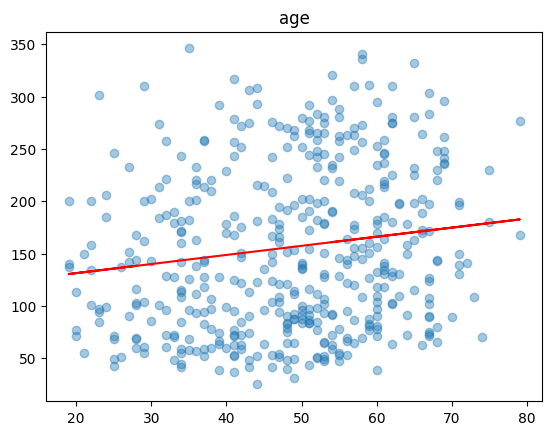

0.04 age


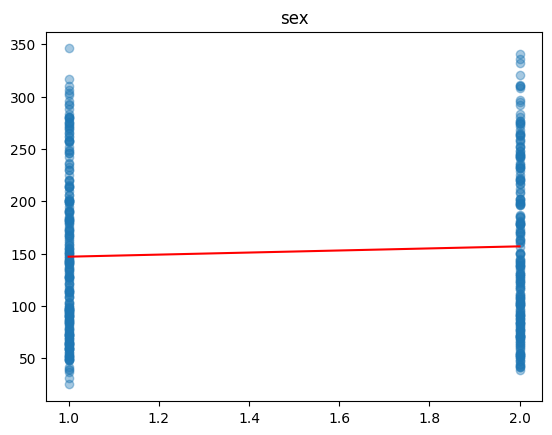

-0.01 sex


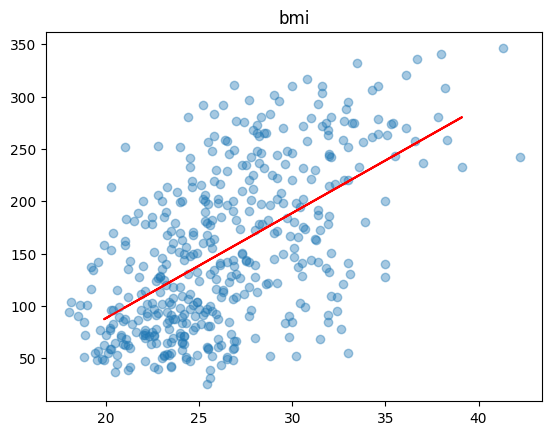

0.38 bmi


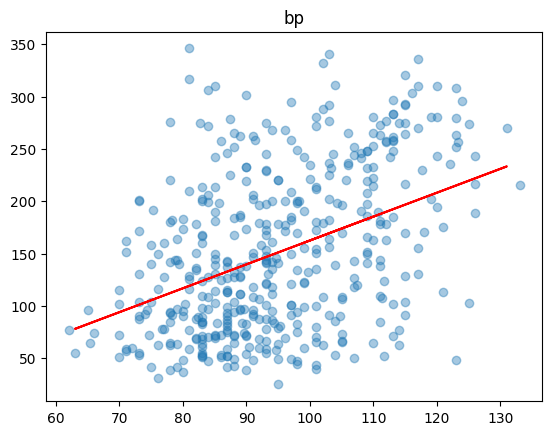

0.25 bp


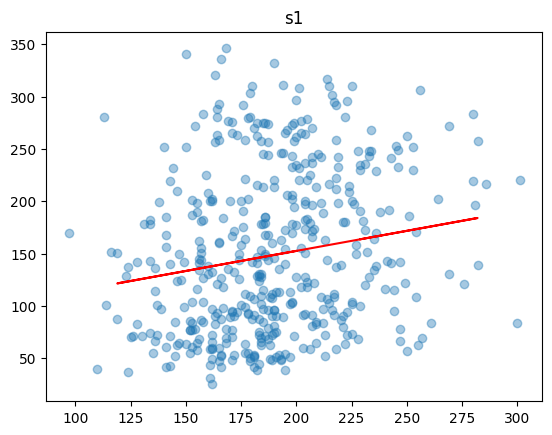

0.04 s1


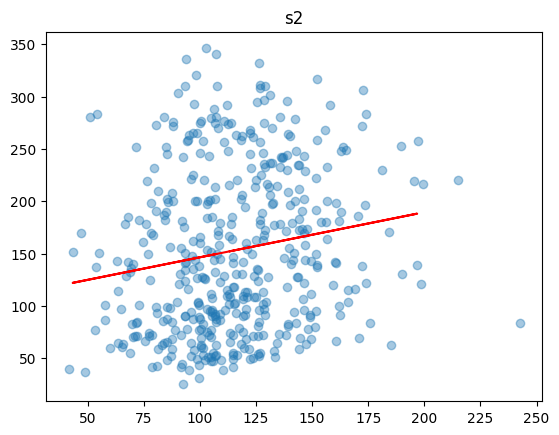

0.03 s2


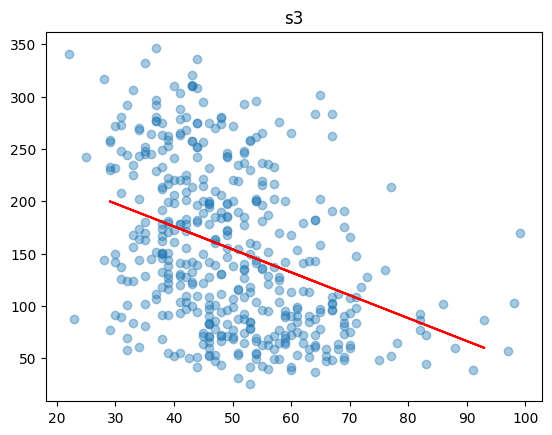

0.2 s3


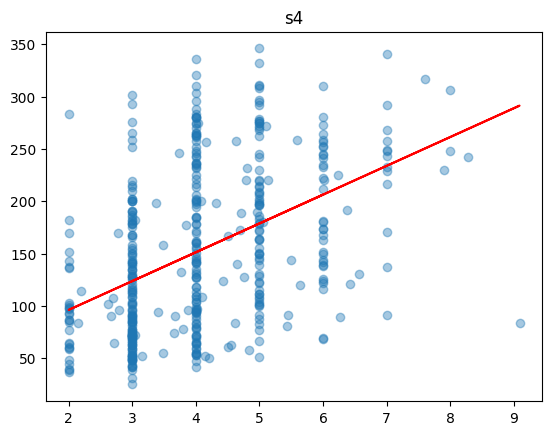

0.1 s4


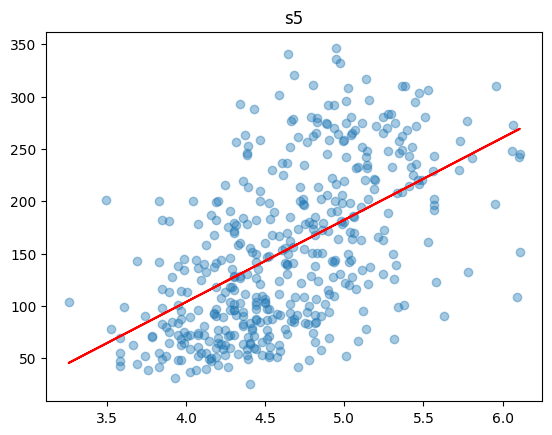

0.43 s5


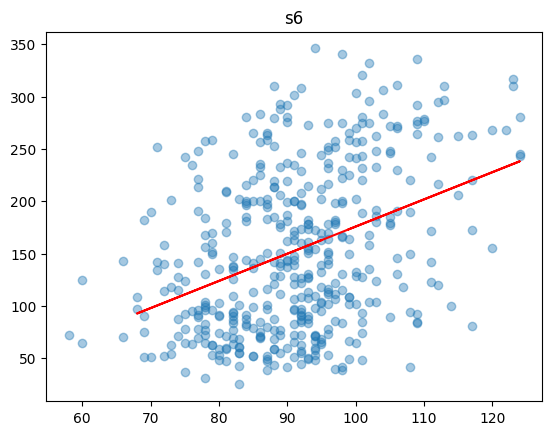

0.13 s6


In [26]:
def plotLR(df, x_feature, y_feature):
  x_train, x_test, y_train, y_test = train_test_split(df[x_feature].values.reshape(-1, 1), df[y_feature], train_size=0.7, test_size=0.3)
  mlr = LinearRegression()
  mlr.fit(x_train, y_train)
  y_prev = mlr.predict(x_test)
  plt.scatter(df[x_feature],df[y_feature], alpha=0.4)
  plt.plot(x_test, y_prev, 'r')
  plt.title(x_feature)
  plt.show()
  plt.close()
  print(round(mlr.score(x_test, y_test), 2), x_feature)

for f in df.columns:
  if df[f].dtype != 'object' and f != 'target':
    plotLR(df, f, 'target')

[ 6.31762633  0.88934797 -1.03967728 -6.39283367 45.93258312  0.20209481]
0.49802939274526714


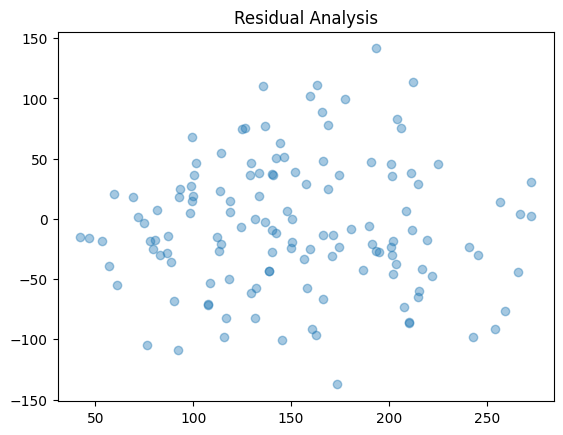

In [27]:
X = X[['bmi', 'bp', 's3', 's4', 's5', 's6']]

x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=6)

regr = LinearRegression()

regr.fit(x_train, y_train)

print(regr.coef_)

y_prev = regr.predict(x_test)

print(regr.score(x_test, y_test))

residuals = y_prev - y_test

plt.scatter(y_prev, residuals, alpha=0.4)
plt.title('Residual Analysis')

plt.show()

